In [8]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [6]:
# Load merged hourly dataset
df = pd.read_csv("../../data_cleaned/merged/02_4_clean_data_daily_mean.csv")
# df = pd.read_csv("../../data_cleaned/merged/02_4_clean_data.csv")
# Convert timestamp columns to datetime
df["period_start_utc"] = pd.to_datetime(df["period_start_utc"], utc=True, errors="coerce")
df["period_end_utc"] = pd.to_datetime(df["period_end_utc"], utc=True, errors="coerce")

# Optional: convert date column if needed
df["date"] = pd.to_datetime(df["date"], errors="coerce")
# Basic cleaning and sorting
# df["gen_forecast_da"] = pd.to_numeric(df["gen_forecast_da"], errors="coerce")
df = df.sort_values("period_start_utc")

df.head(2)

,date,year,month,day,dayofyear,dayofweek,dayofyear_sin1,dayofyear_cos1,dayofweek_sin1,dayofweek_cos1,...,period_end_utc,price,gen_forecast_da,load_forecast_da,on_wind_da,off_wind_da,solar_da,res_sum_da,c_by_day,price_gas
0,2019-01-01,2019,1,1,1,1,0.000000,1.000000,0.781831,0.623490,...,2019-01-02 00:00:00+00:00,-5.873333,47744.070208,61009.409167,31139.542708,4523.792188,413.402396,36076.737292,24,22.28
1,2019-01-02,2019,1,2,2,2,0.017202,0.999852,0.974928,-0.222521,...,2019-01-03 00:00:00+00:00,29.286250,55944.564583,65324.240833,24192.978333,4118.932917,1191.025417,29502.936667,24,22.28


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2557 entries, 0 to 2556
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype              
---  ------            --------------  -----              
 0   date              2557 non-null   datetime64[ns]     
 1   year              2557 non-null   int64              
 2   month             2557 non-null   int64              
 3   day               2557 non-null   int64              
 4   dayofyear         2557 non-null   int64              
 5   dayofweek         2557 non-null   int64              
 6   dayofyear_sin1    2557 non-null   float64            
 7   dayofyear_cos1    2557 non-null   float64            
 8   dayofweek_sin1    2557 non-null   float64            
 9   dayofweek_cos1    2557 non-null   float64            
 10  is_holiday        2557 non-null   int64              
 11  day_type          2557 non-null   object             
 12  period_start_utc  2557 non-null   datetime64[ns, UTC]
 13  per

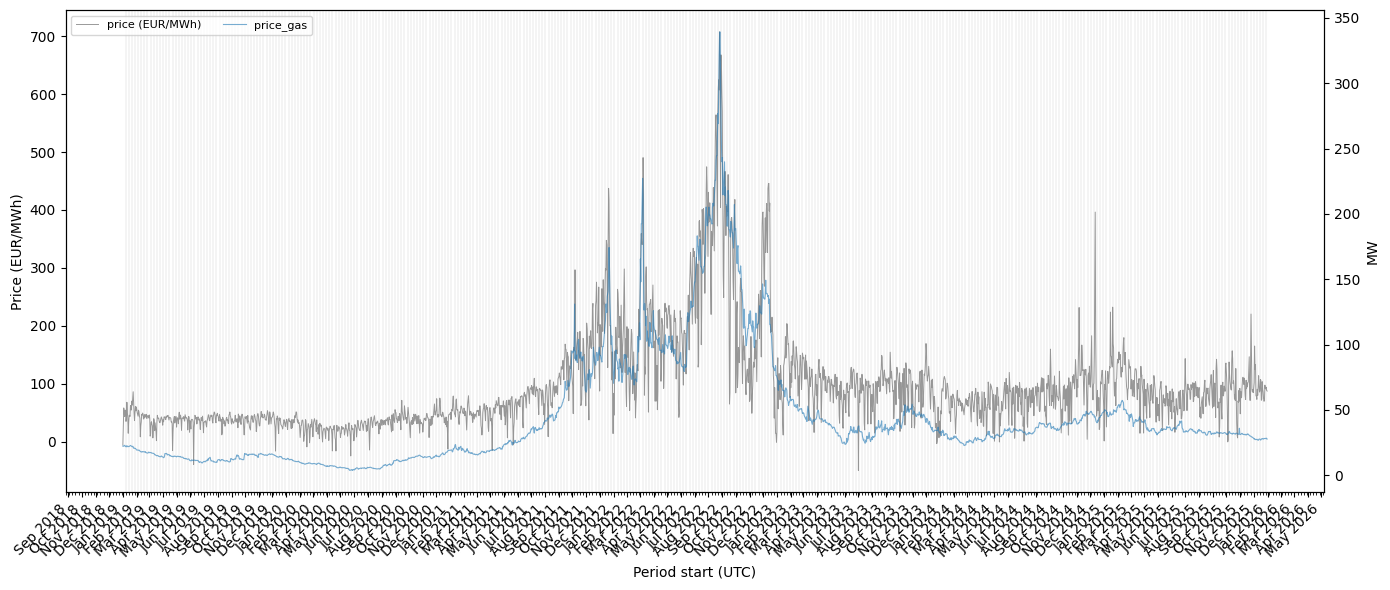

In [15]:

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

feature_cols = ["price_gas"] #, ""load_forecast_da", "res_sum_da"]

df_plot = df.copy()
df_plot["period_start_utc"] = pd.to_datetime(df_plot["period_start_utc"], errors="coerce")
years = [2019,2020,2021,2022,2023,2024,2025]
df_plot = df_plot[df_plot["year"].isin(years)].copy()
df_plot = df_plot.sort_values("period_start_utc")

df_daily = (
    df_plot
    .set_index("period_start_utc")[["price"] + feature_cols]
    .resample("D")
    .mean()
    .reset_index()
)

fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.plot(df_daily["period_start_utc"], df_daily["price"], color="black", alpha=0.4, linewidth=0.7, label="price (EUR/MWh)")
ax1.set_ylabel("Price (EUR/MWh)")
ax1.set_xlabel("Period start (UTC)")

ax2 = ax1.twinx()
for col in feature_cols:
    ax2.plot(df_daily["period_start_utc"], df_daily[col], alpha=0.6, linewidth=0.8, label=col)
ax2.set_ylabel("MW")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", ncol=2, fontsize=8)

# Better month labels + weekly lines
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax1.xaxis.set_minor_locator(mdates.WeekdayLocator(byweekday=mdates.MO))
plt.setp(ax1.get_xticklabels(), rotation=45, ha="right")

for dt in pd.date_range(
    df_daily["period_start_utc"].min(),
    df_daily["period_start_utc"].max(),
    freq="W-MON"
):
    ax1.axvline(dt, color="gray", linewidth=0.3, alpha=0.4)

plt.tight_layout()
plt.show()


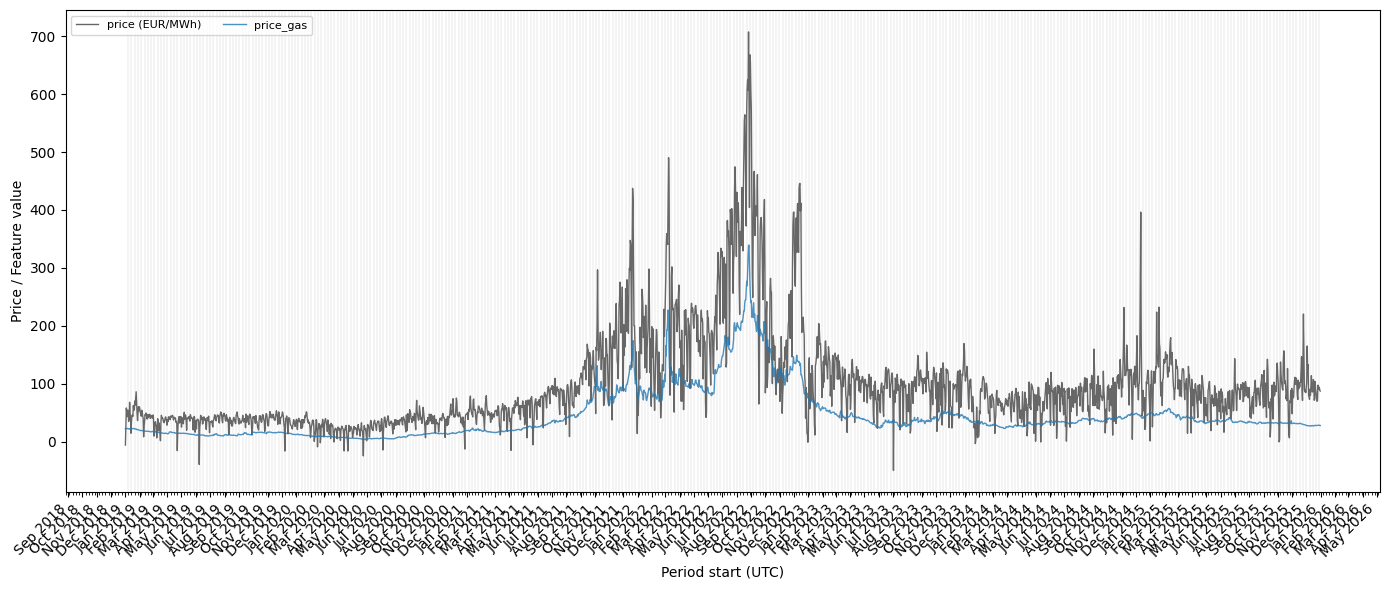

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# same-scale plot -> keep only comparable units here
feature_cols = [
    # "price_gas",
    "load_forecast_da",
    "res_sum_da",
]

df_plot = df.copy()
df_plot["period_start_utc"] = pd.to_datetime(df_plot["period_start_utc"], errors="coerce")
years = [2019, 2020, 2021, 2022, 2023, 2024, 2025]
df_plot = df_plot[df_plot["year"].isin(years)].copy()
df_plot = df_plot.sort_values("period_start_utc")

df_daily = (
    df_plot
    .set_index("period_start_utc")[["price","price_gas"] + feature_cols]
    .resample("D")
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(14, 6))

# one shared y-axis
ax.plot(
    df_daily["period_start_utc"],
    df_daily["price"],
    color="black",
    alpha=0.6,
    linewidth=1.0,
    label="price (EUR/MWh)"
)

for col in feature_cols:
    ax.plot(
        df_daily["period_start_utc"],
        df_daily[col],
        alpha=0.8,
        linewidth=1.0,
        label=col
    )

ax.set_ylabel("Price / Feature value")
ax.set_xlabel("Period start (UTC)")
ax.legend(loc="upper left", ncol=2, fontsize=8)

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_minor_locator(mdates.WeekdayLocator(byweekday=mdates.MO))
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

for dt in pd.date_range(
    df_daily["period_start_utc"].min(),
    df_daily["period_start_utc"].max(),
    freq="W-MON"
):
    ax.axvline(dt, color="gray", linewidth=0.3, alpha=0.4)

plt.tight_layout()
plt.show()


In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

def plot_prices_and_da_features(
    df,
    feature_cols_da=None,
    years=None,
    datetime_col="period_start_utc",
    resample_freq="D",
    figsize=(15, 9),
):
    if feature_cols_da is None:
        feature_cols_da = ["load_forecast_da", "res_sum_da"]
    if years is None:
        years = [2019, 2020, 2021, 2022, 2023, 2024, 2025]

    df_plot = df.copy()
    df_plot[datetime_col] = pd.to_datetime(df_plot[datetime_col], errors="coerce")
    df_plot = df_plot[df_plot[datetime_col].notna()].sort_values(datetime_col)

    if years is not None:
        df_plot = df_plot[df_plot[datetime_col].dt.year.isin(years)]

    cols = ["price", "price_gas"] + feature_cols_da
    cols = [c for c in cols if c in df_plot.columns]

    df_daily = (
        df_plot
        .set_index(datetime_col)[cols]
        .resample(resample_freq)
        .mean()
        .reset_index()
    )

    fig, (ax_top, ax_bottom) = plt.subplots(
        2, 1, figsize=figsize, sharex=True, gridspec_kw={"height_ratios": [1, 1]}
    )

    # Top: prices
    if "price" in df_daily.columns:
        ax_top.plot(df_daily[datetime_col], df_daily["price"], color="black", linewidth=1.0, alpha=0.8, label="price (EUR/MWh)")
    if "price_gas" in df_daily.columns:
        ax_top.plot(df_daily[datetime_col], df_daily["price_gas"], color="tab:blue", linewidth=1.0, alpha=0.8, label="price_gas")
    ax_top.set_ylabel("EUR/MWh")
    ax_top.set_title("Prices")
    ax_top.legend(loc="upper left", fontsize=9)

    # Bottom: DA features
    for col in feature_cols_da:
        if col in df_daily.columns:
            ax_bottom.plot(df_daily[datetime_col], df_daily[col], linewidth=1.0, alpha=0.85, label=col)
    ax_bottom.set_ylabel("MW")
    ax_bottom.set_title("DA Features")
    ax_bottom.set_xlabel("Period start (UTC)")
    ax_bottom.legend(loc="upper left", fontsize=9)

    # X-axis labels yearly
    ax_bottom.xaxis.set_major_locator(mdates.YearLocator())
    ax_bottom.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    plt.setp(ax_bottom.get_xticklabels(), rotation=0, ha="center")

    # Monthly vertical lines
    month_starts = pd.date_range(df_daily[datetime_col].min(), df_daily[datetime_col].max(), freq="MS")
    for dt in month_starts:
        ax_top.axvline(dt, color="gray", linewidth=0.35, alpha=0.35)
        ax_bottom.axvline(dt, color="gray", linewidth=0.35, alpha=0.35)

    plt.tight_layout()
    plt.show()
    return df_daily


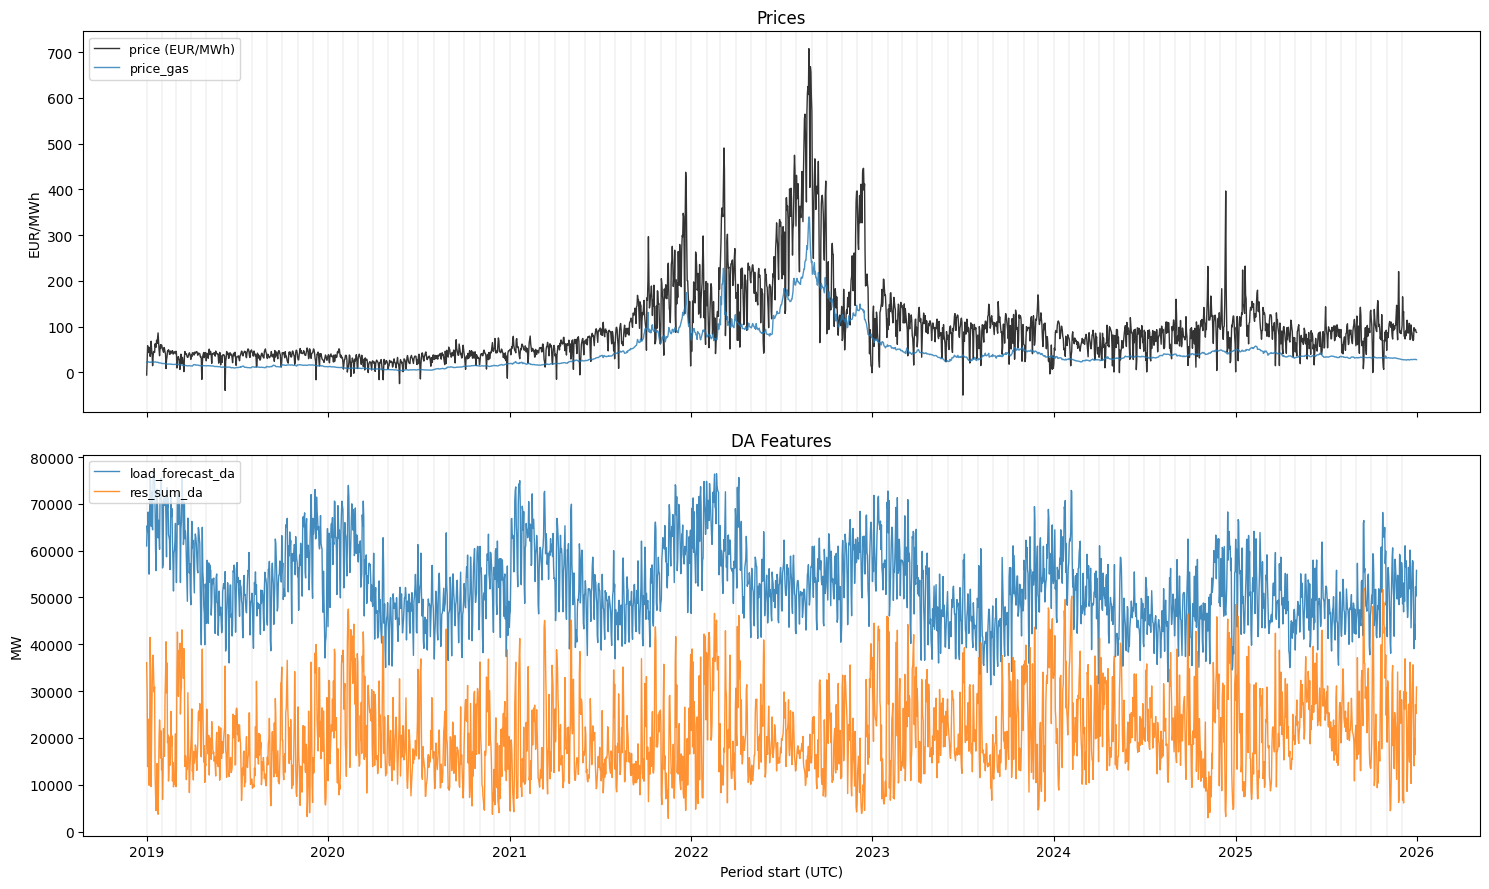

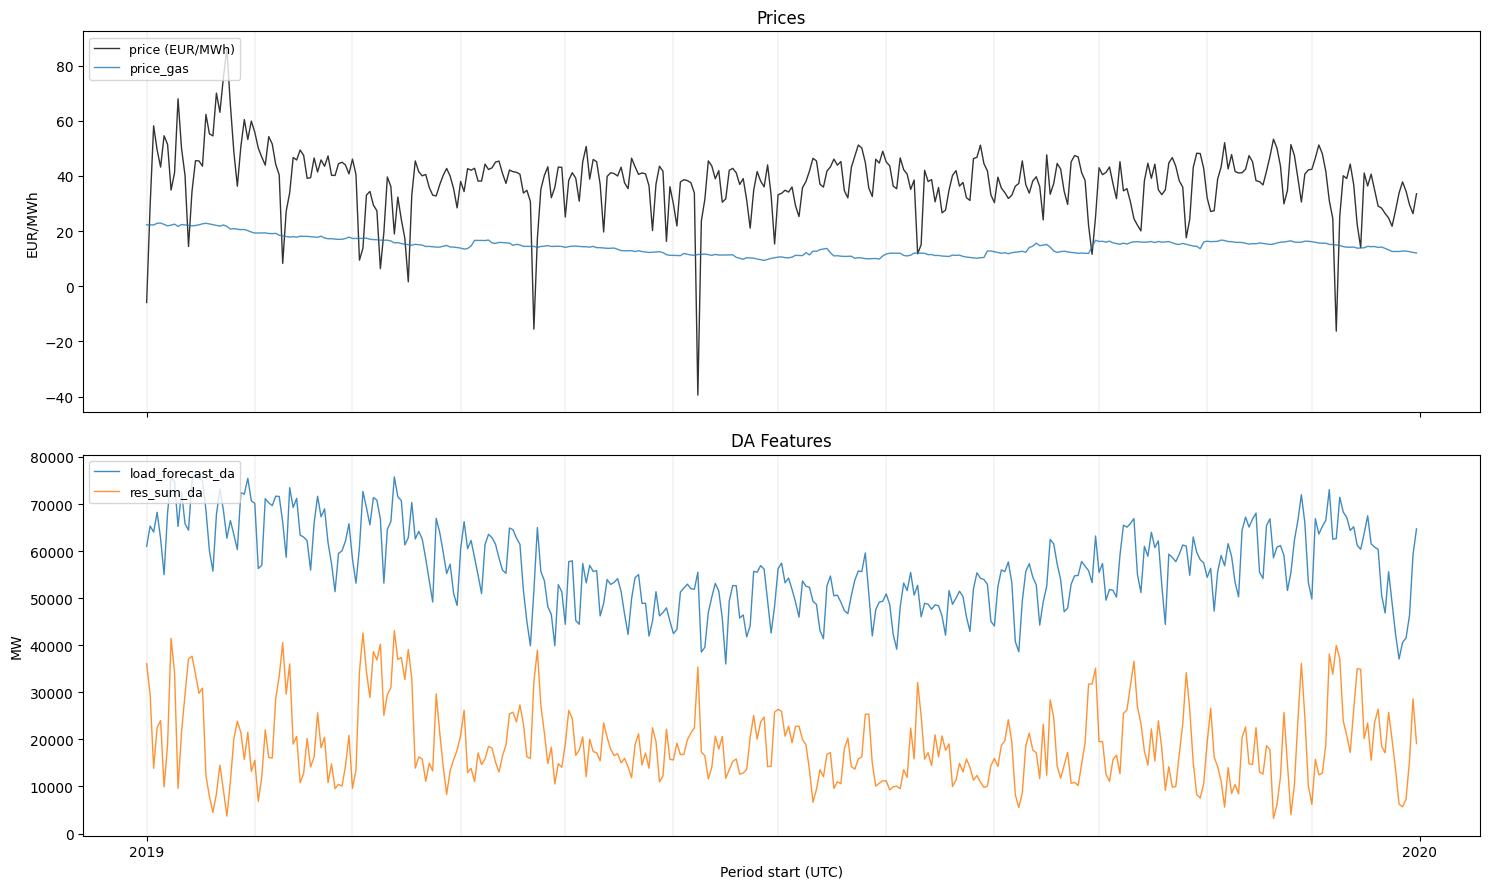

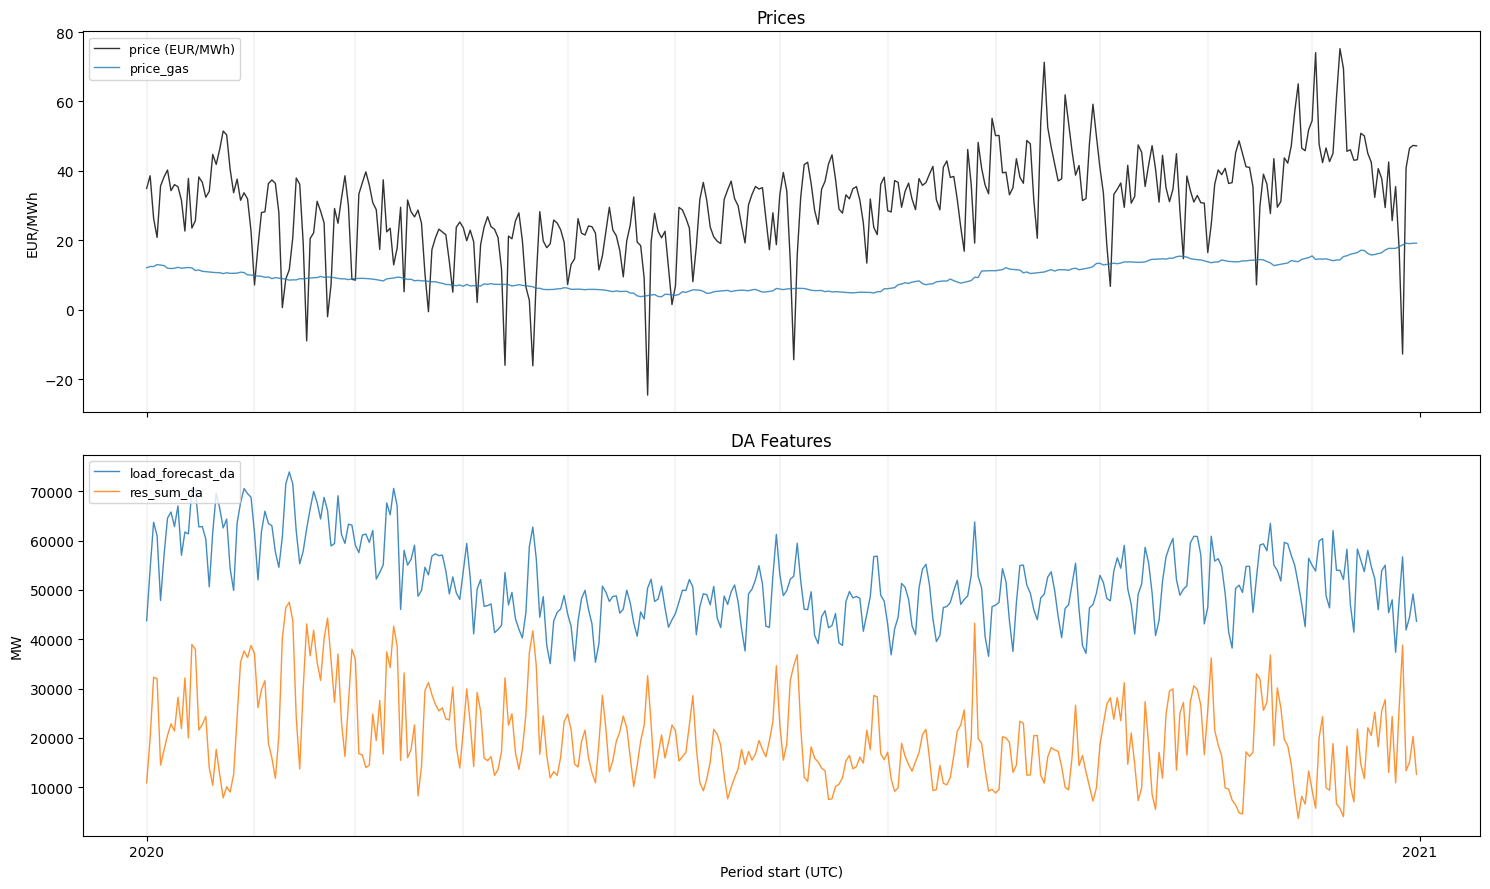

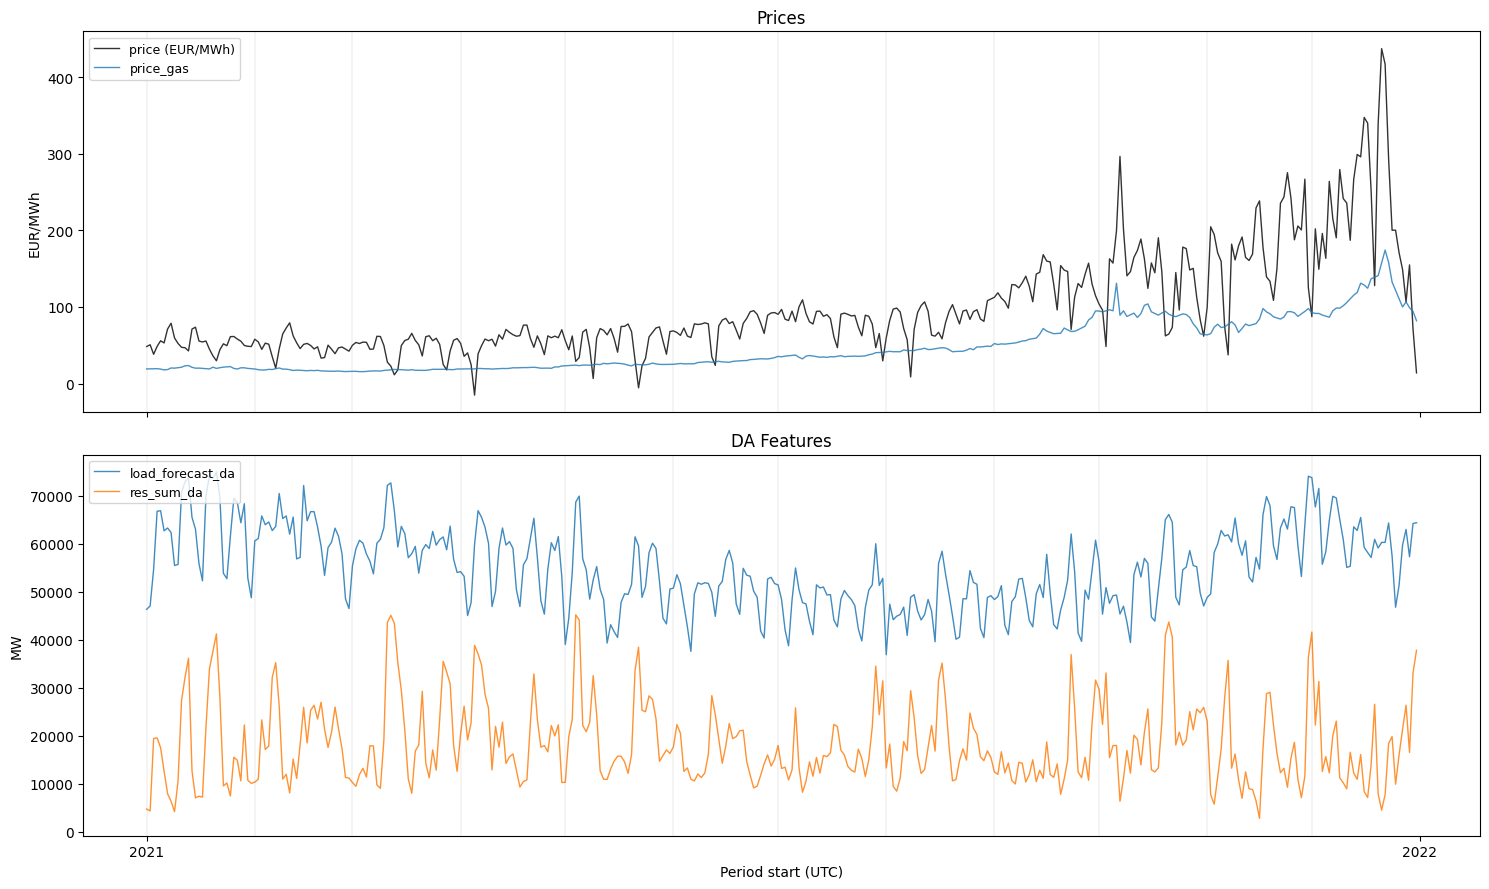

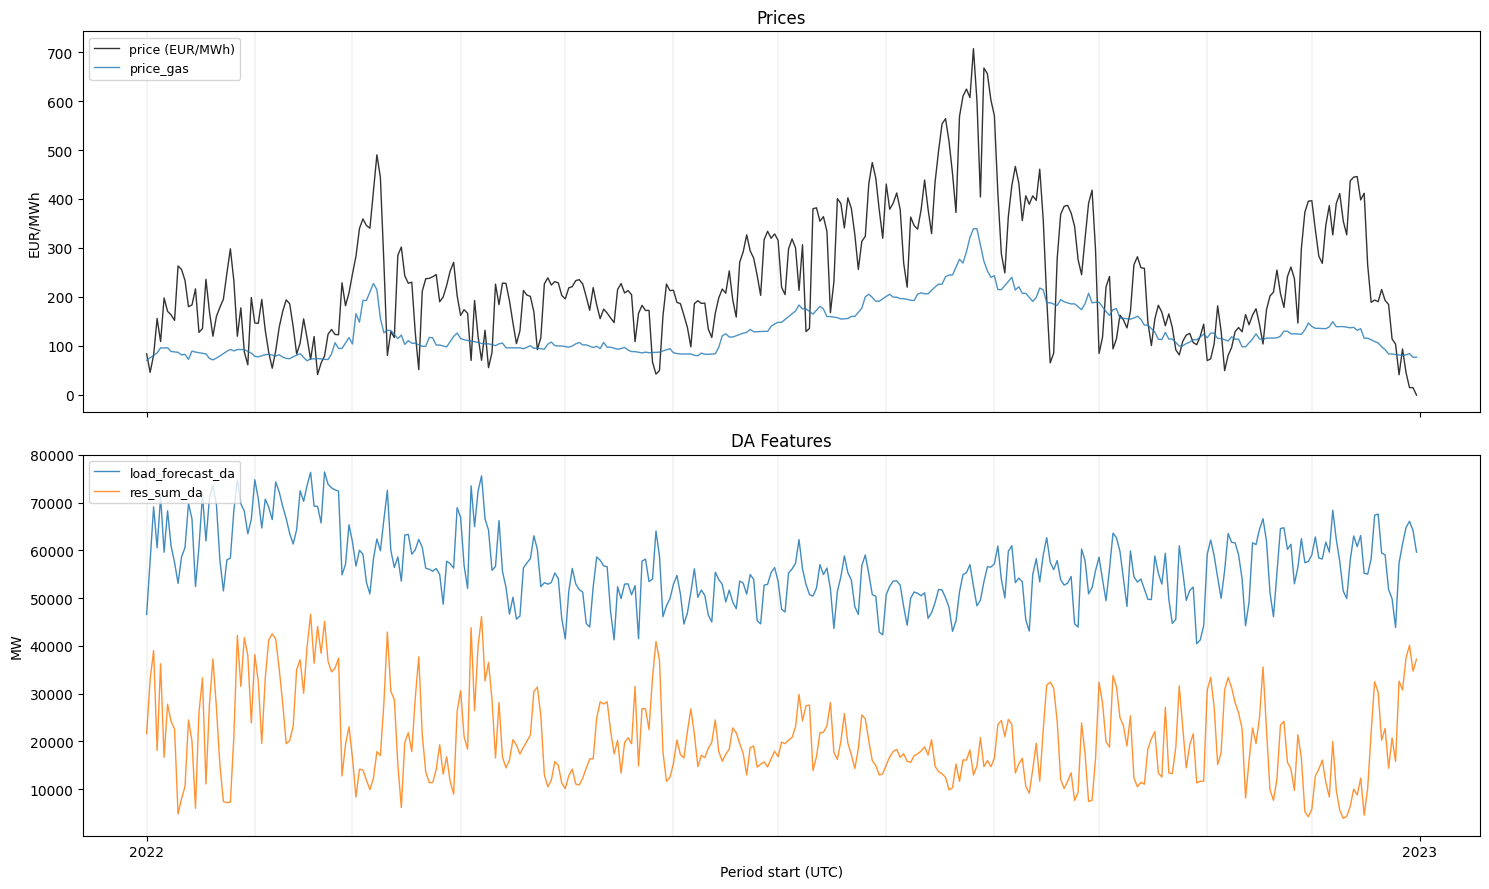

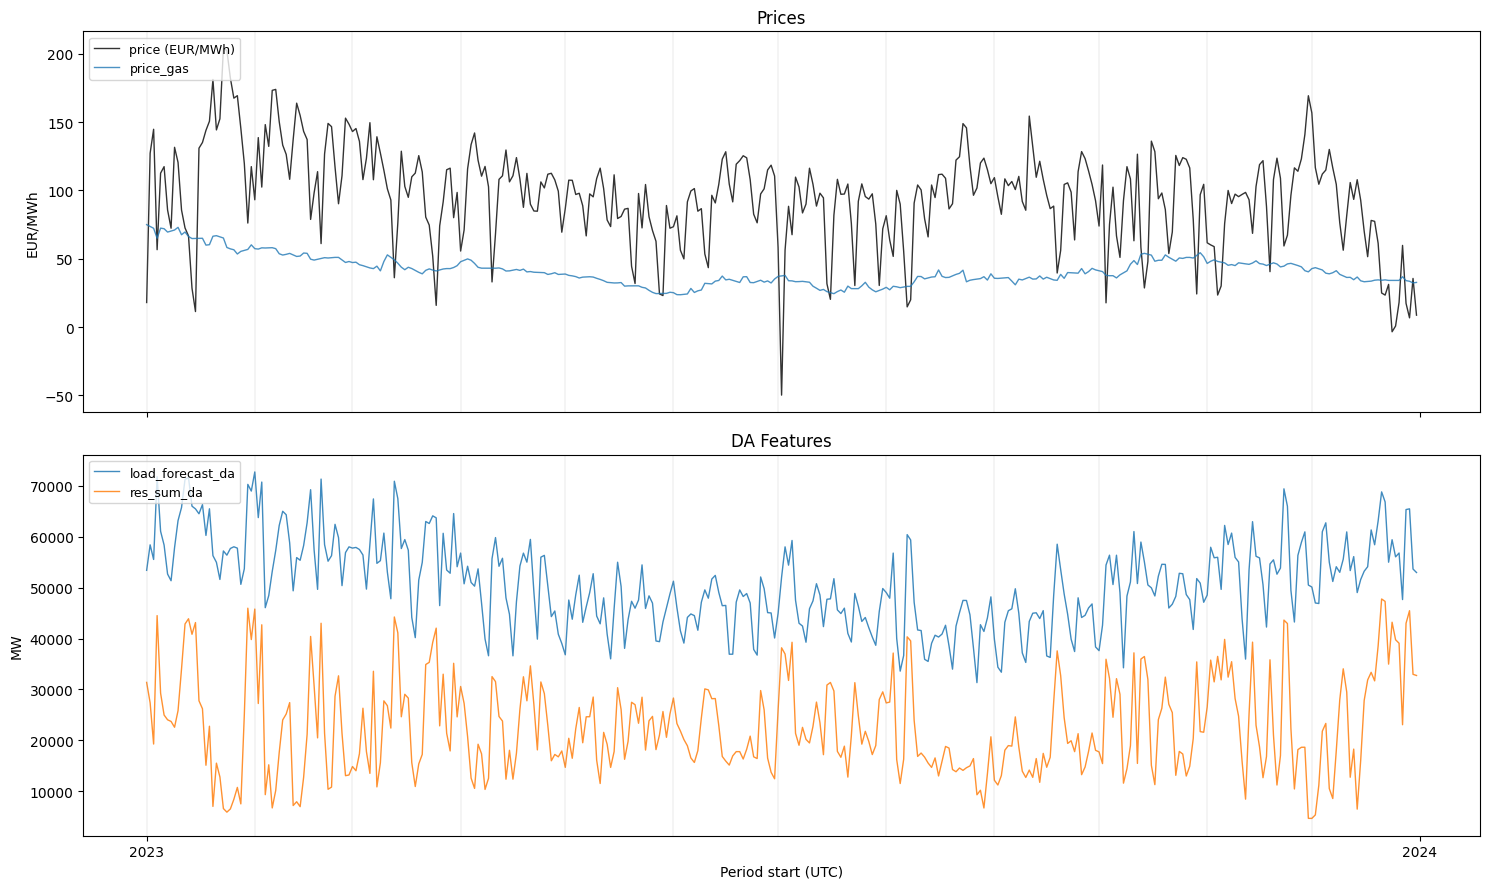

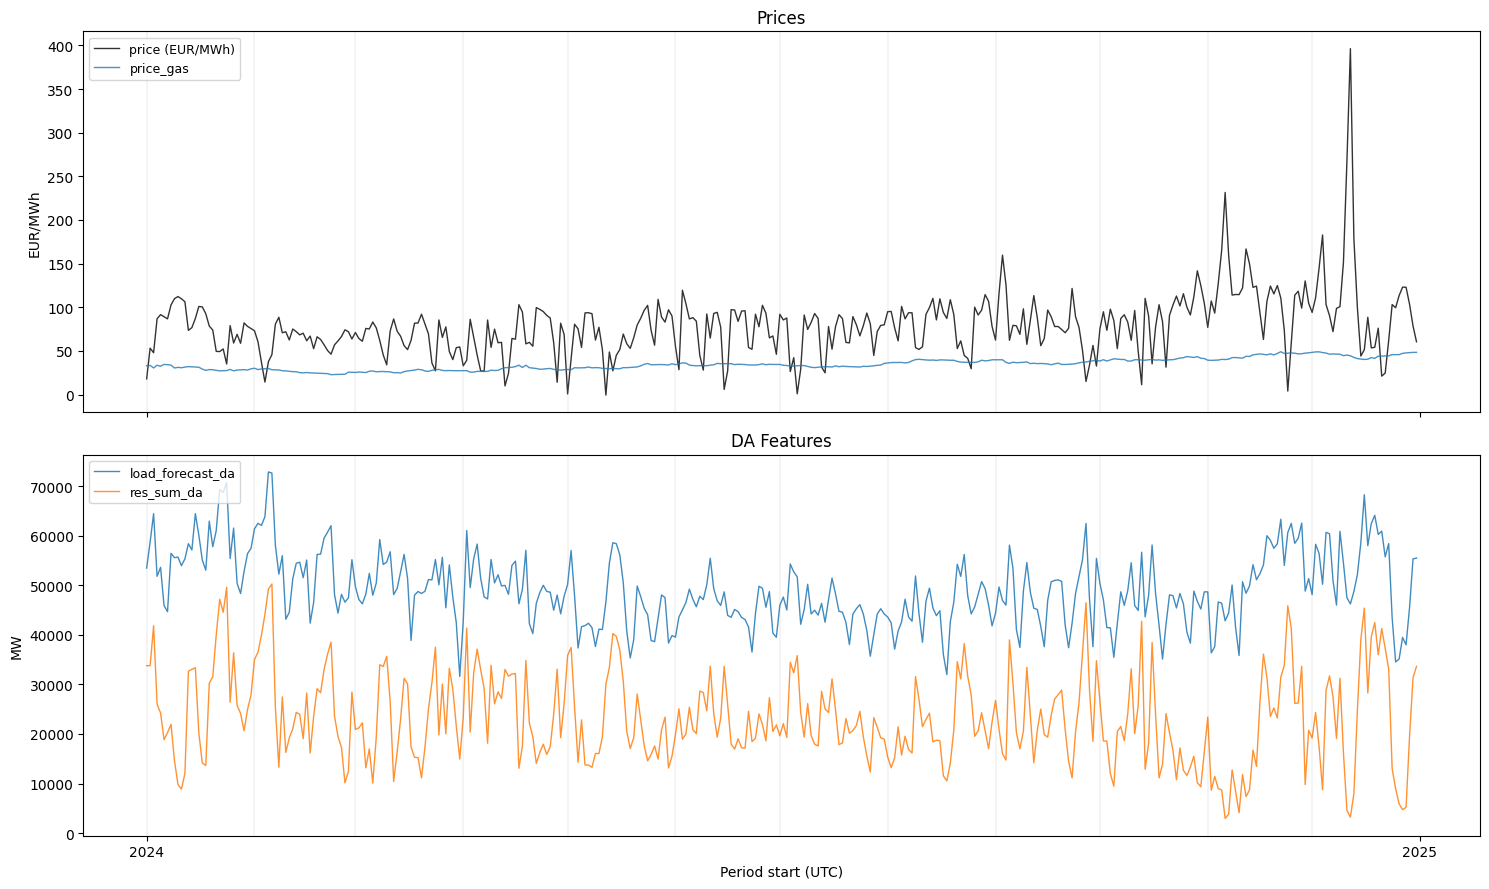

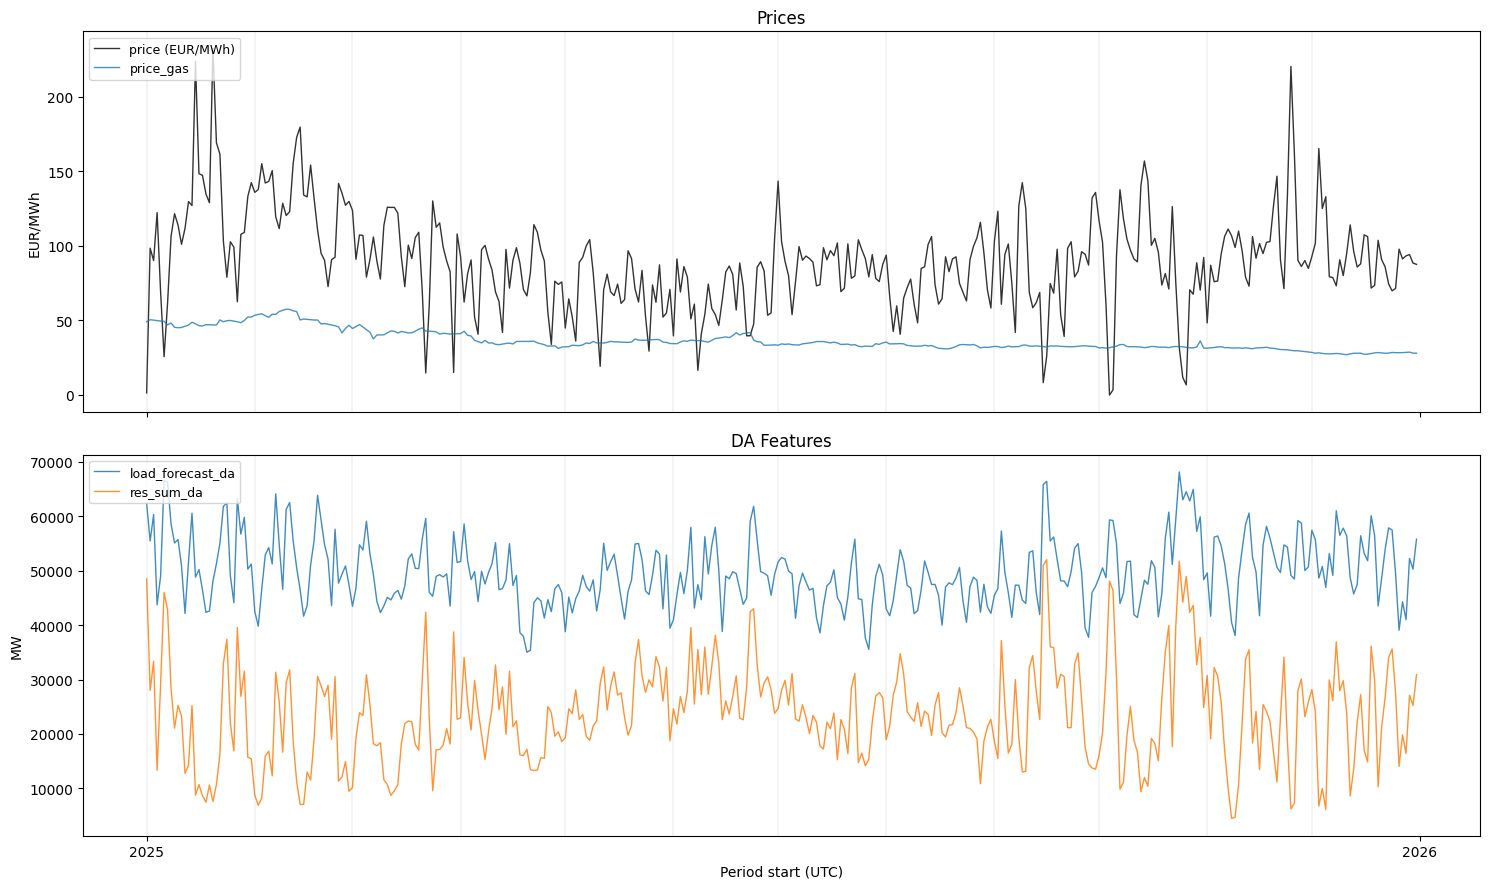

,period_start_utc,price,price_gas,load_forecast_da,res_sum_da
0,2025-01-01 00:00:00+00:00,1.097500,48.8890,62426.415521,48477.436146
1,2025-01-02 00:00:00+00:00,98.241250,50.2150,55458.261354,27989.583229
2,2025-01-03 00:00:00+00:00,89.962500,49.9050,60328.598021,33355.868750
3,2025-01-04 00:00:00+00:00,122.135417,49.6220,43721.576667,13329.348854
4,2025-01-05 00:00:00+00:00,68.913333,49.3610,49010.729167,29095.902188
...,...,...,...,...,...
360,2025-12-27 00:00:00+00:00,91.023333,28.0950,44299.660104,19840.767500
361,2025-12-28 00:00:00+00:00,93.085417,28.2725,41008.039167,16415.139896
362,2025-12-29 00:00:00+00:00,93.948021,28.4500,52262.052813,27115.325833
363,2025-12-30 00:00:00+00:00,88.232292,27.7660,50291.344688,25233.016875


In [27]:
plot_prices_and_da_features(df)
plot_prices_and_da_features(df, years=[2019])
plot_prices_and_da_features(df, years=[2020])
plot_prices_and_da_features(df, years=[2021])
plot_prices_and_da_features(df, years=[2022])
plot_prices_and_da_features(df, years=[2023])
plot_prices_and_da_features(df, years=[2024])
plot_prices_and_da_features(df, years=[2025])
# plot_prices_and_da_features(df, feature_cols_da=["load_forecast_da"])
